# Gaussian linear regression: unbiased LOO by stratified path sampling

For each replicate, draw an index $i$ uniformly in $\{0,\ldots,n-1\}$ and estimate

$$
\log p(y_i \mid y_{-i}) = \int_0^1 \mathbb{E}_{\pi_{i,\lambda}}[\log p(y_i \mid \theta)]\,d\lambda,
$$

where $\pi_{i,0}(\theta)=p(\theta \mid y_{-i})$ and $\pi_{i,1}(\theta)=p(\theta \mid y)$. Multiplying by $n$ gives an unbiased estimator of the total LOO ELPD.


In [1]:
from src import *
from tqdm import tqdm
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.integrate import quad
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")
np.random.seed(2026)


## Simulated Gaussian linear model


In [2]:
n, d = 40, 1
true_theta = np.array([2.5])
X_data = np.random.randn(n, d)
sigma2_noise = 0.4**2
y_data = X_data @ true_theta + np.random.normal(0, np.sqrt(sigma2_noise), size=n)

prior_mean = np.zeros(d)
prior_cov = np.eye(d) * 10.0
prior_precision = np.linalg.inv(prior_cov)

blr_path = BayesianLinearRegressionTempering(
    X_data,
    y_data,
    prior_mean,
    prior_cov,
    sigma2_noise,
)




In [3]:

loo_log_densities_exact, true_value = blr_path.exact_loo_elpd()
print(f"Exact conjugate LOO ELPD: {true_value:.6f}")

Exact conjugate LOO ELPD: -16.294155


## `LOO with path sampling`

The path is the geometric path between the leave-one-out posterior and the full posterior:

$$
\pi_{i,\lambda}(\theta) \propto p(\theta\mid y_{-i})^{1-\lambda}p(\theta\mid y)^\lambda.
$$

Equivalently, up to normalizing constants,

$$
\pi_{i,\lambda}(\theta) \propto p(\theta)\prod_{j\ne i}p(y_j\mid\theta)\,p(y_i\mid\theta)^\lambda.
$$


In [ ]:
loo_index = np.random.randint(n)


def log_target0(theta):
    """Unnormalized log posterior without observation loo_index."""
    return blr_path.log_posterior_minus_i(theta, loo_index)


def log_target1(theta):
    """Unnormalized full log posterior."""
    return blr_path.log_posterior_full(theta)


def log_target_path(theta, path):
    """Geometric path between p(theta | y_-i) and p(theta | y)."""
    return blr_path.log_path(theta, path, loo_index)


def grad_log_target_path(theta):
    """Derivative in lambda of log_target_path(theta, lambda)."""
    return blr_path.log_likelihood_i(theta, loo_index)




Exact conjugate LOO ELPD: -16.294155


In [4]:
L = 20  # 0, 0.1, ..., 1.0
nrep = 10
sigmaq = 1
lag = 1
lambda_grid = np.arange(0, L + 1) / L # uniform grid of lambda values in [0, 1]

In [5]:
lambda_grid

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

Lambda grid: 100%|██████████| 21/21 [00:00<00:00, 45.05it/s]


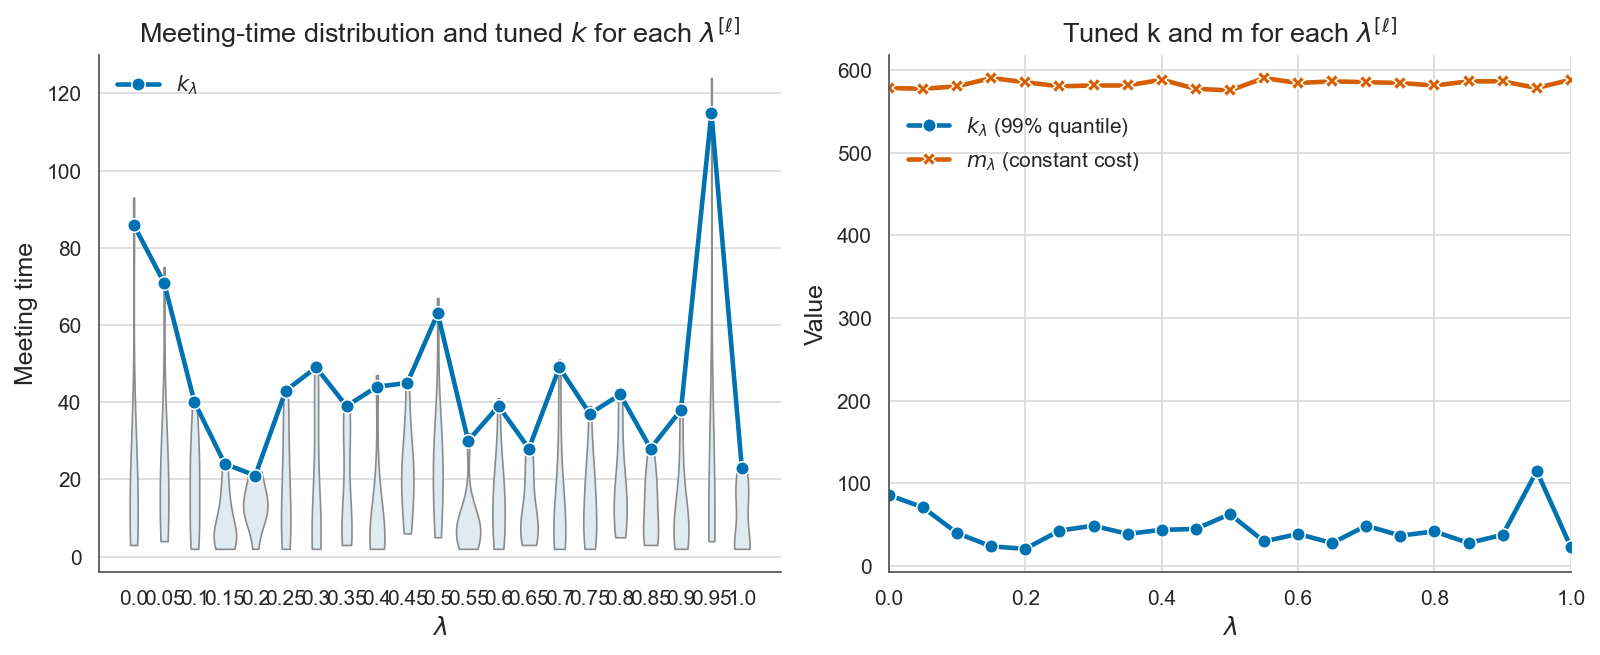

In [6]:
km_grid = tune_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, log_target_path = log_target_path, nrep = nrep)
plot_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, log_target_path = log_target_path, nrep = nrep)

Final estimation: 100%|██████████| 21/21 [00:05<00:00,  3.75it/s]


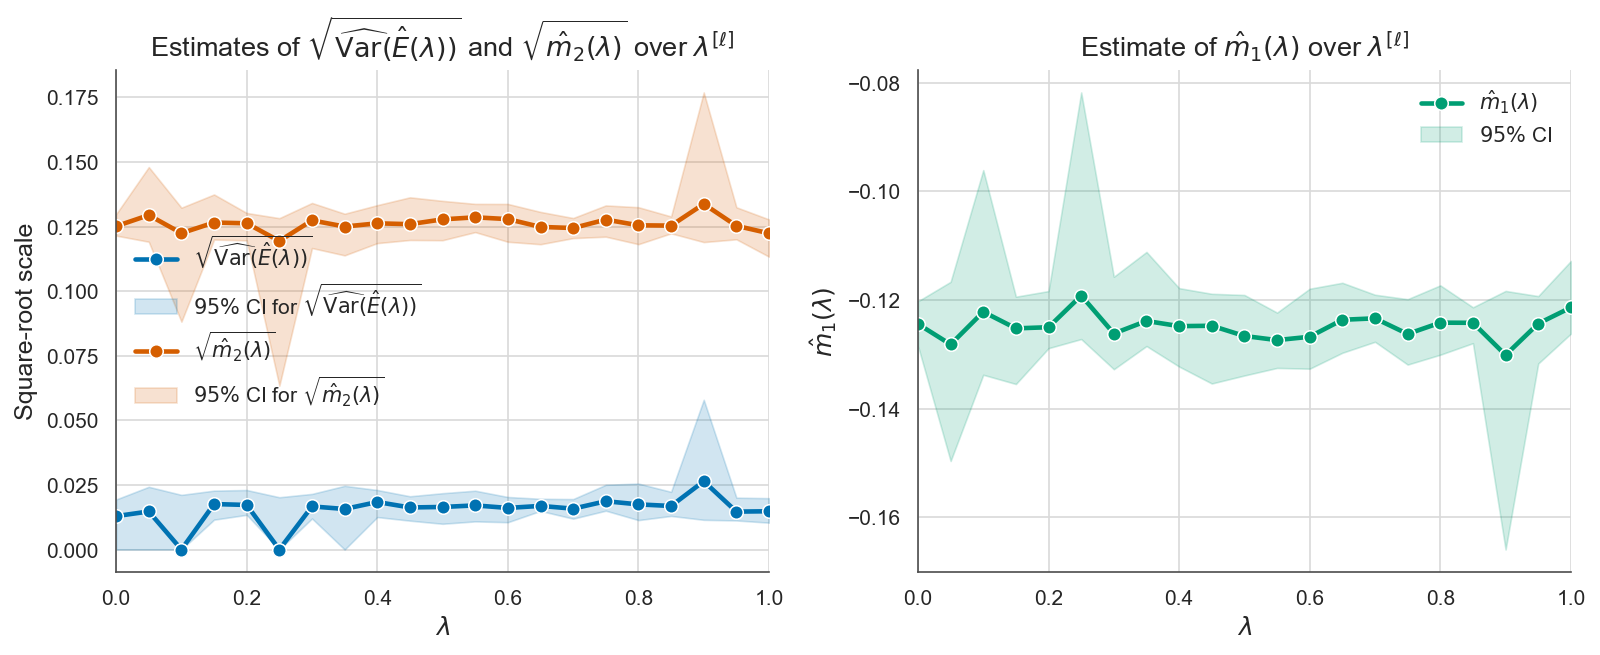

In [7]:
k_grid, m_grid = km_grid["k_grid"], km_grid["m_grid"]
plot_estimate_mom(lambda_grid, k_grid, m_grid, nrep, sigmaq, lag, log_target_path, grad_log_target_path)

In [8]:
res = estimate_sqrt_m2(lambda_grid, k_grid, m_grid, nrep, sigmaq, lag, log_target_path, grad_log_target_path)

Final estimation: 100%|██████████| 21/21 [00:05<00:00,  3.87it/s]


In [11]:


# --- Configuration de l'expérience ---
N_grid = [5, 10, 20]  # Différentes valeurs de N_i
M_budget = 40            # Budget lambda fixe par indice LOO échantillonné
num_replicates = 5       # Nombre de répétitions pour chaque N_i

# Calcul de la vraie valeur de référence (somme totale des LOO ELPD exacts)
loo_log_densities_exact, true_total_loo = blr_path.exact_loo_elpd()

# Initialisation du dictionnaire de cache dynamique comme demandé
# Structure : { loo_index: (mk_grid, sqrt_m2, build_budget) }
parameter_cache = {}

results_mse = []

print("Début des simulations avec tuning et mise en cache dynamique...")
for N_i in N_grid:
    estimates_is = []
    estimates_strat = []
    
    # Barre de progression pour suivre l'avancée des réplications de chaque N_i
    for rep in tqdm(range(num_replicates), desc=f"Simulation N_i={N_i}"):
        
        # Tirage uniforme de N_i indices parmi les n_total lignes (avec remise)
        sampled_indices = np.random.choice(n, size=N_i, replace=True)
        
        running_sum_is = 0.0
        running_sum_strat = 0.0
        
        for idx in sampled_indices:
            
            # --- VÉRIFICATION ET REMPLISSAGE DU CACHE À LA VOLÉE ---
            if idx not in parameter_cache:
                # Si l'indice n'a jamais été rencontré, on fait le tuning maintenant
                def log_target_path_i(theta, path):
                    return blr_path.log_path(theta, path, idx)
                
                def grad_log_target_path_i(theta):
                    return blr_path.log_likelihood_i(theta, idx)
                
                mk_grid_i = tune_km_grid(lambda_grid, lag=lag, sigmaq=sigmaq, log_target_path=log_target_path_i, nrep=nrep)
                # Calcul de sqrt_m2 nécessaire pour la proposal q et stratified
                sqrt_m2_i = estimate_sqrt_m2(lambda_grid, mk_grid_i["k_grid"], mk_grid_i["m_grid"], nrep, sigmaq, lag, log_target_path_i, grad_log_target_path_i)

                estimator_i = lambda lam: uestimator_given_lambda(lam, lambda_grid, mk_grid_i["k_grid"], mk_grid_i["m_grid"], sigmaq, lag, log_target_path_i, grad_log_target_path_i)

                budget_i = build_budget(L, M_budget, estimator_i, n_samples_per_bin=10)

                # Stockage direct dans le cache
                parameter_cache[idx] = (mk_grid_i, sqrt_m2_i, budget_i)
            
            # --- RÉCUPÉRATION DU CACHE (Efficience Computationnelle) ---
            # Si déjà calculé précédemment (ou au-dessus), l'accès prend O(1)
            mk_grid_i, sqrt_m2_i, budget_i = parameter_cache[idx]
            
            # Redéfinition des fonctions pour les passer aux estimateurs
            def log_target_path_i(theta, path):
                return blr_path.log_path(theta, path, idx)
            
            def grad_log_target_path_i(theta):
                return blr_path.log_likelihood_i(theta, idx)
            
            estimator_i = lambda lam: uestimator_given_lambda(lam, lambda_grid, mk_grid_i["k_grid"], mk_grid_i["m_grid"], sigmaq, lag, log_target_path_i, grad_log_target_path_i)

            # --- Estimateur 1 : Stratified Sampling ---
            est_strat_i = optimal_startified_estimator(L, estimator_i, budget_i)
            
            # --- Estimateur 2 : Importance Sampling (q unbiased) ---
            est_is_i = q_unbiased_estimator(L, M_budget, estimator_i, sqrt_m2_i)
            
            running_sum_strat += est_strat_i
            running_sum_is += est_is_i
            
        # Redressement de l'estimateur pour l'ensemble du dataset (n / N_i)
        total_est_strat = (n / N_i) * running_sum_strat
        total_est_is = (n / N_i) * running_sum_is
        
        estimates_strat.append(total_est_strat)
        estimates_is.append(total_est_is)
        
    # Calcul des MSE globaux pour la taille N_i courante
    mse_strat = np.mean((np.array(estimates_strat) - true_value) ** 2)
    mse_is = np.mean((np.array(estimates_is) - true_value) ** 2)
    
    results_mse.append({
        "N_i": N_i,
        "MSE_Stratified": mse_strat,
        "MSE_Importance_Sampling": mse_is
    })

# Affichage des résultats sous forme de tableau de données
df_results = pd.DataFrame(results_mse)
print("\n--- Résultats du MSE pour différents N_i ---")
print(df_results)
print(f"\nNombre total d'indices uniques tunés et mis en cache : {len(parameter_cache)} / {n}")

Début des simulations avec tuning et mise en cache dynamique...


Simulation N_i=20: 100%|██████████| 5/5 [05:28<00:00, 65.72s/it]


--- Résultats du MSE pour différents N_i ---
   N_i  MSE_Stratified  MSE_Importance_Sampling
0    5       76.419443                76.667913
1   10       21.185153                23.377550
2   20      136.137627                95.635750

Nombre total d'indices uniques tunés et mis en cache : 40 / 40


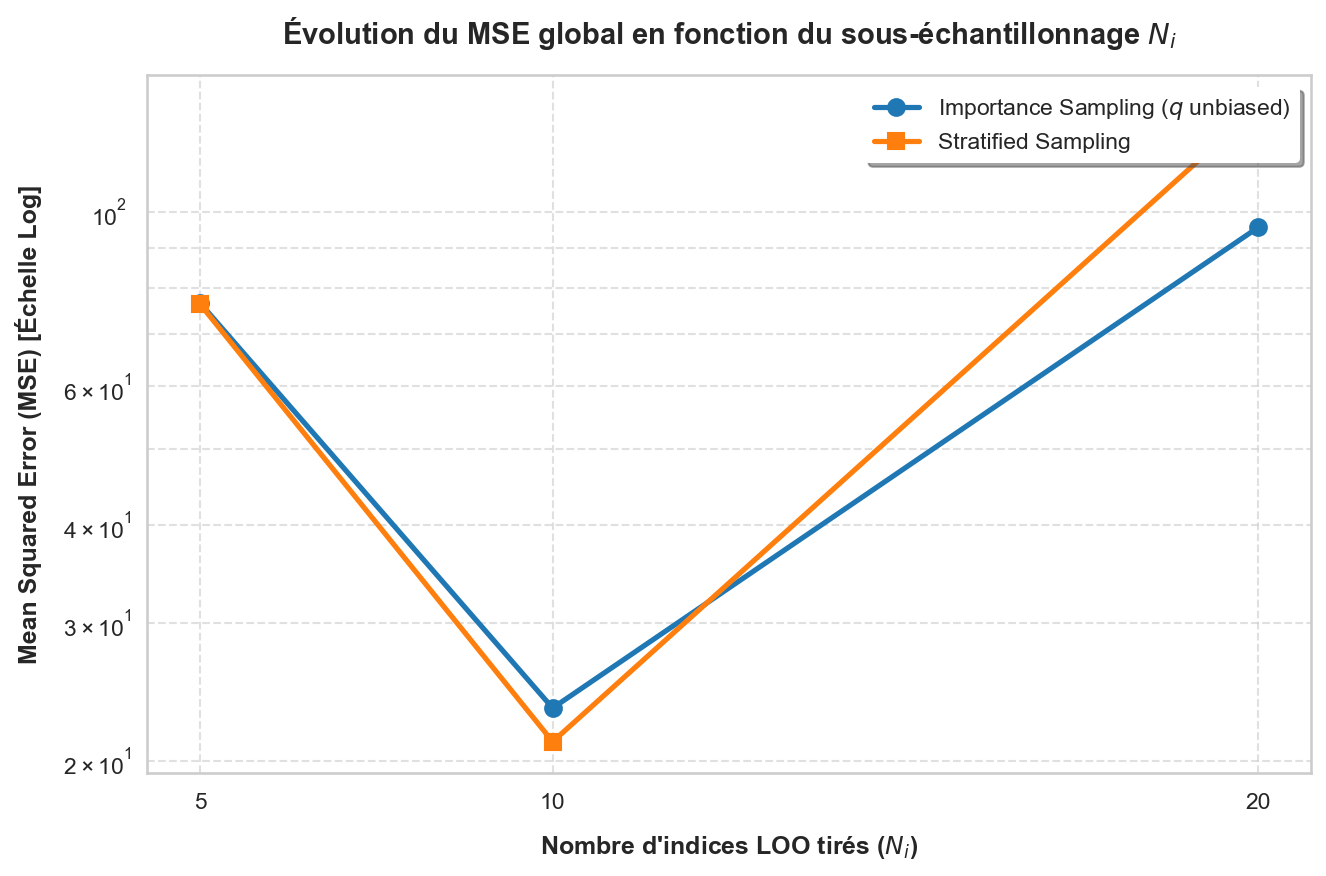

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Application d'un style épuré et professionnel
sns.set_theme(style="whitegrid")

# Création de la figure
plt.figure(figsize=(9, 6), dpi=150)

# Tracé pour Importance Sampling
plt.plot(
    df_results["N_i"], 
    df_results["MSE_Importance_Sampling"], 
    marker="o", 
    markersize=8,
    linewidth=2.5, 
    color="#1f77b4",
    label="Importance Sampling ($q$ unbiased)"
)

# Tracé pour Stratified Sampling
plt.plot(
    df_results["N_i"], 
    df_results["MSE_Stratified"], 
    marker="s", 
    markersize=8,
    linewidth=2.5, 
    color="#ff7f0e",
    label="Stratified Sampling"
)

# Configuration des axes et mise en échelle log pour le MSE
plt.yscale("log")
plt.xlabel("Nombre d'indices LOO tirés ($N_i$)", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Mean Squared Error (MSE) [Échelle Log]", fontsize=12, fontweight='bold', labelpad=10)
plt.title("Évolution du MSE global en fonction du sous-échantillonnage $N_i$", fontsize=14, fontweight='bold', pad=15)

# Forcer l'affichage de toutes les valeurs de N_i sur l'axe X pour éviter les graduations floues
plt.xticks(df_results["N_i"], labels=[str(n) for n in df_results["N_i"]], fontsize=11)
plt.yticks(fontsize=11)

# Style de la grille d'arrière-plan (grilles principales et secondaires pour le log)
plt.grid(True, which="both", linestyle="--", alpha=0.6)

# Personnalisation de la légende
plt.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none", shadow=True, fontsize=11)

# Ajustement pour éviter que les labels ne débordent
plt.tight_layout()

# Affichage du plot
plt.show()

In [7]:
M_budget = 40
tuning_cache = {}
for idx in tqdm(range(n), desc="Processing indices"):  # Vérification de la validité de l'indice
                # Si l'indice n'a jamais été rencontré, on fait le tuning maintenant
    def log_target_path_i(theta, path):
        return blr_path.log_path(theta, path, idx)
    
    def grad_log_target_path_i(theta):
        return blr_path.log_likelihood_i(theta, idx)
    
    mk_grid_i = tune_km_grid(lambda_grid, lag=lag, sigmaq=sigmaq, log_target_path=log_target_path_i, nrep=nrep)
    # Calcul de sqrt_m2 nécessaire pour la proposal q et stratified
    sqrt_m2_i = estimate_sqrt_m2(lambda_grid, mk_grid_i["k_grid"], mk_grid_i["m_grid"], nrep, sigmaq, lag, log_target_path_i, grad_log_target_path_i)

    estimator_i = lambda lam: uestimator_given_lambda(lam, lambda_grid, mk_grid_i["k_grid"], mk_grid_i["m_grid"], sigmaq, lag, log_target_path_i, grad_log_target_path_i)

    budget_i = build_budget(L, M_budget, estimator_i, n_samples_per_bin=10)

    # Stockage direct dans le cache
    tuning_cache[idx] = (mk_grid_i, sqrt_m2_i, budget_i)

Processing indices:  12%|█▎        | 5/40 [01:05<07:38, 13.11s/it]


KeyboardInterrupt: 